# Make figures for the SCA comparison

Snow-Informed Reservoir Operations (SIRO)

USACE-ERDC-CRREL

July 2026

In [1]:
import os
from glob import glob
import xarray as xr
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from tqdm import tqdm
import numpy as np
import seaborn as sns
import geopandas as gpd
import xrspatial

plt.rcParams.update({'font.size': 12, 'font.sans-serif': 'Arial'})

# I/O
BASE_DIR = "/Users/rdcrlrka/Research/SIRO/MCS_SCA/"
OUT_DIR = os.path.join(BASE_DIR, "SCA_comparison_results_SPIReS")
FIG_DIR = os.path.join(BASE_DIR, "figures_SPIReS")
AOI_FILE = os.path.join(BASE_DIR, "..", "MCS_outline.gpkg")
os.makedirs(FIG_DIR, exist_ok=True)

# Satellite-based fSCA
SPIRES_FSCA_FILE = os.path.join(OUT_DIR, "SPIReS_fSCA.nc")
LS_FSCA_FILE = os.path.join(OUT_DIR, "Landsat_fSCA.nc")

# Landsat images
LS_IMAGE_DICT = {
    date: sorted(glob(os.path.join(BASE_DIR, "Landsat_images", f"*{date}*SR_B*.TIF")))
    for date in ["20241205", "20250114"]
}

# Model names
MODEL_NAMES = ["HMS-EB", "HMS-TI", "iSnobal", "SnowModel"]

# Compiled result filess
METRICS_FILE = os.path.join(OUT_DIR, "compiled_performance_metrics.nc")
METRICS_BINNED_FILE = os.path.join(OUT_DIR, "compiled_metrics_binned_elev_aspect.nc")
MELT_OUT_BINNED_FILE = os.path.join(OUT_DIR, "compiled_melt_out_binned_elev_aspect.nc")
MELT_OUT_GRIDS_FILE = os.path.join(OUT_DIR, "melt_out_dates_gridded.nc")

# One gridded file per model
MODEL_GRID_FILES = {
    m: os.path.join(OUT_DIR, f"fSCA_regridded_{m}.nc") for m in MODEL_NAMES
}

for file in [SPIRES_FSCA_FILE, METRICS_FILE, METRICS_BINNED_FILE]:
    if not os.path.exists(file):
        print("Could not locate file:", file)
for m, f in MODEL_GRID_FILES.items():
    if not os.path.exists(f):
        print(f"Could not locate gridded file for {m}:", f)


## Define some color palettes

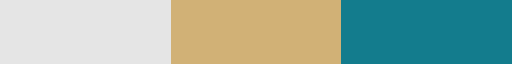

In [2]:
sca_cmap = matplotlib.colors.ListedColormap([
    "#e5e5e5",   # 0.0  -> no snow
    "#d1b176",   # 0.5  -> uncertain
    "#137C8D"   # 1.0  -> snow
])
sca_cmap.set_bad("#ffffff")  # NaN (unobserved)
# Boundaries centered so 0, 0.5, 1 fall in the middle of each color band
sca_cmap_norm = matplotlib.colors.BoundaryNorm([-0.25, 0.25, 0.75, 1.25], sca_cmap.N)
sca_cmap

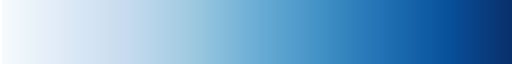

In [3]:
blues_colors = plt.colormaps['Blues'](np.linspace(0, 1, 256))
blues_colors[0] = [1.0, 1.0, 1.0, 1.0]
fsca_cmap = matplotlib.colors.ListedColormap(blues_colors)
fsca_cmap_norm = matplotlib.colors.Normalize(vmin=0, vmax=100)
fsca_cmap

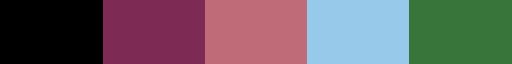

In [4]:
ds_colors_dict = {
    "SPIReS":  "#000000",
    "HMS-EB":       "#7D2B54",
    "HMS-TI":       "#BF6B78",
    "iSnobal":      "#97CAEA",
    "SnowModel":    "#37753B"
}
ds_colors = list(ds_colors_dict.values())
ds_cmap = matplotlib.colors.ListedColormap(ds_colors)
ds_cmap


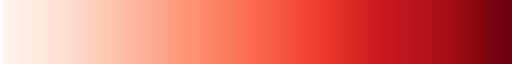

In [5]:
reds_colors = plt.colormaps['Reds'](np.linspace(0, 1, 256))
reds_colors[0] = [1.0, 1.0, 1.0, 1.0]
error_cmap = matplotlib.colors.ListedColormap(reds_colors)
error_cmap_norm = matplotlib.colors.Normalize(vmin=0, vmax=100)
error_cmap

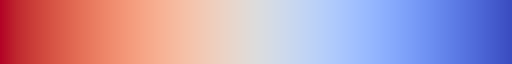

In [6]:
derr_cmap = plt.cm.coolwarm_r
derr_cmap_norm = matplotlib.colors.Normalize(vmin=-10, vmax=10)
derr_cmap

## fSCA time series

In [16]:
# from rasterio.enums import Resampling
# PS_FILE = "/Users/rdcrlrka/Research/SIRO/MCS_SCA/Archive/PSS_SCA/2024-06-11_land_cover_mask.tif"

# with xr.open_dataset(SPIRES_FSCA_FILE, mask_and_scale=True) as spires_fsca:
#     target_grid = spires_fsca.snow_fraction
#     target_grid = target_grid.rio.write_crs("EPSG:32611")

# with xr.open_dataset(PS_FILE, mask_and_scale=True).band_data as ds:
#     tree_mask = xr.where(np.isnan(ds), np.nan, ds==2)
#     tree_mask = tree_mask.rio.write_crs("EPSG:32611")
#     tree_mask_reproj = tree_mask.rio.reproject_match(target_grid, reasmpling=Resampling.average)

# tree_mask_reproj.plot(cmap="Greens")

### Both tasks

In [ ]:
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [2.5, 1]})
fig.subplots_adjust(wspace=0.15)

# create NaN array to concat with each dataset to prevent lines from connecting where there are no data
nan_da = xr.DataArray(
    np.array([np.nan]*4), 
    coords={'time': [np.datetime64(f"{year}-08-01") for year in [2022, 2023, 2024, 2025]]}
)

# Load SPIReS and Landsat fSCA
with xr.open_dataset(SPIRES_FSCA_FILE, mask_and_scale=True) as spires_fsca:
    spires_fsca_mean = spires_fsca.snow_fraction.mean(dim=['x', 'y'])
    spires_fsca_mean_plot = xr.concat([spires_fsca_mean, nan_da], dim='time').sortby('time')

with xr.open_dataset(LS_FSCA_FILE, mask_and_scale=True) as ls_fsca:
    ls_fsca_mean = ls_fsca.band_data.mean(dim=['x', 'y'])


# Prepare a list to collect difference dataframes for the boxplot
diff_df_list = []

# Models
for m in MODEL_GRID_FILES.keys():
    with xr.open_dataset(MODEL_GRID_FILES[m], mask_and_scale=True) as m_fsca:
        m_fsca_mean = m_fsca.mean(dim=['x', 'y']).fSCA * 100
        
        # Calculate min, max, and mean across all tasks and SWE thresholds
        m_min = m_fsca_mean.min(dim=['task', 'SWE_threshold_m'])
        m_max = m_fsca_mean.max(dim=['task', 'SWE_threshold_m'])
        m_mean = m_fsca_mean.mean(dim=['task', 'SWE_threshold_m'])
        
        # Add NaNs for plotting breaks
        m_min_plot = xr.concat([m_min, nan_da], dim='time').sortby('time')
        m_max_plot = xr.concat([m_max, nan_da], dim='time').sortby('time')
        m_mean_plot = xr.concat([m_mean, nan_da], dim='time').sortby('time')

        # Fill between encompasses all tasks and SWE thresholds now
        ax[0].fill_between(
            m_mean_plot.time, m_min_plot, m_max_plot, 
            color=ds_colors_dict[m], alpha=0.5
        )    
        ax[0].plot(
            m_mean_plot.time, m_mean_plot, 
            color=ds_colors_dict[m], label=m
        )
        
        # --- Box plot data prep ---
        # Align times between model and SPIReS to calculate valid differences (dropping added NaNs)
        m_clean = m_mean.dropna(dim='time')
        spires_clean = spires_fsca_mean.dropna(dim='time')
        
        m_aligned, spires_aligned = xr.align(m_clean, spires_clean, join='inner')
        diff = m_aligned - spires_aligned
        
        # Convert to DataFrame for Seaborn
        df = diff.to_dataframe(name='Difference').reset_index()
        df['Model'] = m
        df['Month'] = df['time'].dt.month
        diff_df_list.append(df)

# Plot SPIReS and Landsat fSCA
ax[0].plot(spires_fsca_mean_plot.time, spires_fsca_mean_plot.data, 
           color=ds_colors_dict["SPIReS"], label="SPIReS")
# ax[0].plot(
#     ls_fsca_mean.time, ls_fsca_mean.data, color='k', linestyle='None', 
#     marker='*', markersize=10, label="Landsat"
# )

# Plot dates being shown in next figure
for date in LS_IMAGE_DICT.keys():
    ax[0].axvline(
        np.datetime64(f"{date[0:4]}-{date[4:6]}-{date[6:]}"), 
        color='k', linestyle='--', alpha=0.8
        )

# --- Format time series panel ---
ax[0].set_ylabel("fSCA [%]")
ax[0].set_xlim(np.datetime64("2022-09-01"), np.datetime64("2025-07-01"))
ax[0].set_ylim(0,105)

# Label years as major x-axis, months as minor x-axis
ax[0].xaxis.set_major_locator(matplotlib.dates.YearLocator())
ax[0].xaxis.set_minor_locator(matplotlib.dates.MonthLocator(bymonth=[1,4,7,10]))
ax[0].xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y'))
ax[0].xaxis.set_minor_formatter(matplotlib.dates.DateFormatter('%b 1'))
ax[0].tick_params(axis='x', which='major', rotation=0, labelsize=12)
ax[0].tick_params(axis='x', which='minor', rotation=0, labelsize=10)
ax[0].grid(which='major', alpha=0.8)
ax[0].grid(which='minor', alpha=0.2)

# --- Format boxplot panel ---
all_diffs = pd.concat(diff_df_list, ignore_index=True)

# Define water year order
water_year_months = [10, 11, 12, 1, 2, 3, 4, 5, 6]
water_year_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Filter dataframe to only include the target water year months
water_year_diffs = all_diffs[all_diffs['Month'].isin(water_year_months)]

# Plot difference boxplots ordered the water year
sns.boxplot(
    data=water_year_diffs, x='Month', y='Difference', hue='Model', 
    order=water_year_months, palette=ds_colors_dict, ax=ax[1], 
    showfliers=False, linecolor='auto'
)
# Make whisker colors match box colors
for patch, line in zip(ax[1].artists, ax[1].lines):
    color = patch.get_facecolor()
    patch.set_edgecolor(color)
    line.set_color(color)

# Map the numeric x-ticks to string month abbreviations
ax[1].set_xticklabels(water_year_labels)

# Adjustments
ax[1].set_ylabel("Modeled - SPIReS fSCA [%]")
ax[1].grid(axis='y', alpha=0.3)  # Horizontal reference grid lines
ax[1].axhline(0, color='k', alpha=0.6, linestyle='-', linewidth=1)

# Draw vertical separator lines in between months
num_months = len(water_year_months)
for x in np.arange(0.5, num_months - 0.5, 1.0):
    ax[1].axvline(x, color='k', alpha=0.6, linestyle='-', linewidth=1)

# Remove seaborn's legend
ax[1].legend_.remove() 

# --- Shared Figure Formatting ---
handles, labels = ax[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels, loc='upper center', ncols=6, frameon=False,
    handletextpad=0.3, bbox_to_anchor=(0.5, 1.05)
)

fig_file = os.path.join(FIG_DIR, "fSCA_timeseries_and_diffs.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("fSCA figure saved to:", fig_file)

plt.show()


### Task 1 only

In [ ]:
# Create figure
fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [2.5, 1]})
fig.subplots_adjust(wspace=0.15)

# create NaN array to concat with each dataset to prevent lines from connecting where there are no data
nan_da = xr.DataArray(
    np.array([np.nan]*4), 
    coords={'time': [np.datetime64(f"{year}-08-01") for year in [2022, 2023, 2024, 2025]]}
)

# Load SPIReS and Landsat fSCA
with xr.open_dataset(SPIRES_FSCA_FILE, mask_and_scale=True) as spires_fsca:
    spires_fsca_mean = spires_fsca.snow_fraction.mean(dim=['x', 'y'])
    spires_fsca_mean_plot = xr.concat([spires_fsca_mean, nan_da], dim='time').sortby('time')

with xr.open_dataset(LS_FSCA_FILE, mask_and_scale=True) as ls_fsca:
    ls_fsca_mean = ls_fsca.band_data.mean(dim=['x', 'y'])


# Prepare a list to collect difference dataframes for the boxplot
diff_df_list = []

# Models
for m in MODEL_GRID_FILES.keys():
    with xr.open_dataset(MODEL_GRID_FILES[m], mask_and_scale=True) as m_fsca:
        m_fsca_mean = m_fsca.mean(dim=['x', 'y']).fSCA * 100

        # SELECT TASK 1 ONLY
        m_fsca_mean = m_fsca_mean.isel(task=0)
        
        # Calculate min, max, and mean across all tasks and SWE thresholds
        m_min = m_fsca_mean.min(dim=['SWE_threshold_m'])
        m_max = m_fsca_mean.max(dim=['SWE_threshold_m'])
        m_mean = m_fsca_mean.mean(dim=['SWE_threshold_m'])
        
        # Add NaNs for plotting breaks
        m_min_plot = xr.concat([m_min, nan_da], dim='time').sortby('time')
        m_max_plot = xr.concat([m_max, nan_da], dim='time').sortby('time')
        m_mean_plot = xr.concat([m_mean, nan_da], dim='time').sortby('time')

        # Fill between encompasses all tasks and SWE thresholds now
        ax[0].fill_between(
            m_mean_plot.time, m_min_plot, m_max_plot, 
            color=ds_colors_dict[m], alpha=0.5
        )    
        ax[0].plot(
            m_mean_plot.time, m_mean_plot, 
            color=ds_colors_dict[m], label=m
        )
        
        # --- Box plot data prep ---
        # Align times between model and SPIReS to calculate valid differences (dropping added NaNs)
        m_clean = m_mean.dropna(dim='time')
        spires_clean = spires_fsca_mean.dropna(dim='time')
        
        m_aligned, spires_aligned = xr.align(m_clean, spires_clean, join='inner')
        diff = m_aligned - spires_aligned
        
        # Convert to DataFrame for Seaborn
        df = diff.to_dataframe(name='Difference').reset_index()
        df['Model'] = m
        df['Month'] = df['time'].dt.month
        diff_df_list.append(df)

# Plot SPIReS and Landsat fSCA
ax[0].plot(spires_fsca_mean_plot.time, spires_fsca_mean_plot.data, 
           color=ds_colors_dict["SPIReS"], label="SPIReS")
# ax[0].plot(
#     ls_fsca_mean.time, ls_fsca_mean.data, color='k', linestyle='None', 
#     marker='*', markersize=10, label="Landsat"
# )

# Plot dates being shown in next figure
for date in LS_IMAGE_DICT.keys():
    ax[0].axvline(
        np.datetime64(f"{date[0:4]}-{date[4:6]}-{date[6:]}"), 
        color='k', linestyle='--', alpha=0.8
        )

# --- Format time series panel ---
ax[0].set_ylabel("fSCA [%]")
ax[0].set_xlim(np.datetime64("2022-09-01"), np.datetime64("2025-07-01"))
ax[0].set_ylim(0,105)

# Label years as major x-axis, months as minor x-axis
ax[0].xaxis.set_major_locator(matplotlib.dates.YearLocator())
ax[0].xaxis.set_minor_locator(matplotlib.dates.MonthLocator(bymonth=[1,4,7,10]))
ax[0].xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y'))
ax[0].xaxis.set_minor_formatter(matplotlib.dates.DateFormatter('%b 1'))
ax[0].tick_params(axis='x', which='major', rotation=0, labelsize=12)
ax[0].tick_params(axis='x', which='minor', rotation=0, labelsize=10)
ax[0].grid(which='major', alpha=0.8)
ax[0].grid(which='minor', alpha=0.2)

# --- Format boxplot panel ---
all_diffs = pd.concat(diff_df_list, ignore_index=True)

# Define water year order
water_year_months = [10, 11, 12, 1, 2, 3, 4, 5, 6]
water_year_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Filter dataframe to only include the target water year months
water_year_diffs = all_diffs[all_diffs['Month'].isin(water_year_months)]

# Plot difference boxplots ordered the water year
sns.boxplot(
    data=water_year_diffs, x='Month', y='Difference', hue='Model', 
    order=water_year_months, palette=ds_colors_dict, ax=ax[1], 
    showfliers=False, linecolor='auto'
)
# Make whisker colors match box colors
for patch, line in zip(ax[1].artists, ax[1].lines):
    color = patch.get_facecolor()
    patch.set_edgecolor(color)
    line.set_color(color)

# Map the numeric x-ticks to string month abbreviations
ax[1].set_xticklabels(water_year_labels)

# Adjustments
ax[1].set_ylabel("Modeled - SPIReS fSCA [%]")
ax[1].grid(axis='y', alpha=0.3)  # Horizontal reference grid lines
ax[1].axhline(0, color='k', alpha=0.6, linestyle='-', linewidth=1)

# Draw vertical separator lines in between months
num_months = len(water_year_months)
for x in np.arange(0.5, num_months - 0.5, 1.0):
    ax[1].axvline(x, color='k', alpha=0.6, linestyle='-', linewidth=1)

# Remove seaborn's legend
ax[1].legend_.remove() 

# --- Shared Figure Formatting ---
handles, labels = ax[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels, loc='upper center', ncols=6, frameon=False,
    handletextpad=0.3, bbox_to_anchor=(0.5, 1.05)
)

fig_file = os.path.join(FIG_DIR, "fSCA_timeseries_and_diffs_TASK1.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("fSCA figure saved to:", fig_file)

plt.show()


## Map view examples

In [ ]:
aoi = gpd.read_file(AOI_FILE)

num_dates = len(LS_IMAGE_DICT.keys())
fig, ax = plt.subplots(num_dates, 6, figsize=(4*6, 5 * num_dates), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.0, wspace=-0.14)

# Normalize bands to brighten
def normalize_band(band, vmin=0, vmax=0.4):
    clipped = np.clip(band, vmin, vmax)
    return (clipped - vmin) / (vmax - vmin)

for i, date in enumerate(LS_IMAGE_DICT.keys()):

    # --- RGB image ---
    rgb_array = []
    for band in ["B4", "B3", "B2"]: # B4=Red, B3=Green, B2=Blue
        band_file = [f for f in LS_IMAGE_DICT[date] if band in f][0]
        
        with xr.open_dataset(band_file).squeeze() as band_ds:
            # Reproject and clip the band to the AOI boundary
            band_ds = band_ds.rio.reproject("EPSG:32611")
            band_ds = band_ds.rio.clip(aoi.geometry)
            # Scale the data to reflectance values
            band_scaled = ((band_ds * 0.0000275) - 0.2).band_data.data
            # Normalize
            band_scaled = normalize_band(band_scaled)
            rgb_array.append(band_scaled)

    # Stack the bands
    rgb_image = np.dstack(rgb_array)
    
    # Identify the background
    outside_aoi_mask = np.isnan(rgb_image).any(axis=2)
    
    # Fill NaN background areas with white
    rgb_image[outside_aoi_mask] = 1.0

    # Plot the result
    ax[i,0].imshow(
        rgb_image, extent=(min(band_ds.x), max(band_ds.x), min(band_ds.y), max(band_ds.y))
        )
    ax[0,0].set_title("Landsat RGB", fontweight='bold', color='k')

    # --- SPIReS fSCA ---
    with xr.open_dataset(SPIRES_FSCA_FILE, mask_and_scale=True).squeeze() as spires_fsca:
        spires_fsca_dt = spires_fsca.sel(time=np.datetime64(f"{date[0:4]}-{date[4:6]}-{date[6:]}"), method='nearest').snow_fraction
    ax[i,1].imshow(
        spires_fsca_dt.data, cmap=fsca_cmap, norm=fsca_cmap_norm,
        extent=(min(spires_fsca.x), max(spires_fsca.x), min(spires_fsca.y), max(spires_fsca.y))
        )
    ax[0,1].set_title("SPIReS", fontweight='bold', color='k')

    # Date label
    ax[i,0].set_ylabel(
        f"{date[0:4]}-{date[4:6]}-{date[6:]}", rotation='horizontal', ha='right'
        )

    # --- Models fSCA ---
    for j, model in enumerate(MODEL_GRID_FILES.keys()):
        with xr.open_dataset(MODEL_GRID_FILES[model], mask_and_scale=True).squeeze() as model_fsca:
            model_fsca_dt = model_fsca.sel(time=np.datetime64(f"{date[0:4]}-{date[4:6]}-{date[6:]}"), method='nearest').fSCA
        model_fsca_dt = model_fsca_dt.mean(dim=['task', 'SWE_threshold_m']) * 100
        ax[i,j+2].imshow(
            model_fsca_dt.data, cmap=fsca_cmap, norm=fsca_cmap_norm,
            extent=(min(model_fsca.x), max(model_fsca.x), min(model_fsca.y), max(model_fsca.y))
            )
        ax[0,j+2].set_title(model, fontweight='bold', color=ds_colors_dict[model])    


# More axes adjustments
for axis in ax.flatten():
    axis.set_xticks([])
    axis.set_yticks([])
    aoi.plot(ax=axis, facecolor="None", edgecolor='k')

# Colorbar
cax = fig.add_axes([0.45, 0.05, 0.1, 0.02])
cbar = fig.colorbar(
    matplotlib.cm.ScalarMappable(cmap=fsca_cmap, norm=fsca_cmap_norm),
    orientation='horizontal', cax=cax
)
cbar.ax.set_title("fSCA [%]", fontsize=12)

# Save
fig_file = os.path.join(FIG_DIR, "fSCA_example_map_views.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)

plt.show()


## fSCA Error with terrain

In [9]:
def plot_recall_polar(terrain_bin_da, elev_bin_edges, aspect_bin_edges, cmap, cmap_norm, ax=None):
    # Create the axis if needed
    if ax==None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='polar')

    ax.set_theta_zero_location('N')     # top = N
    ax.set_theta_direction(-1)          # Clockwise

    # Get bin centers and widths for elevation and aspect
    elev_bin_width = elev_bin_edges[1] - elev_bin_edges[0]
    elev_centers = (elev_bin_edges[1:] + elev_bin_edges[:-1]) / 2
    aspect_bin_width = aspect_bin_edges[1] - aspect_bin_edges[0]
    aspect_centers = (aspect_bin_edges[:-1] + aspect_bin_edges[1:]) / 2
    theta_centers = np.deg2rad(aspect_centers)

    # Iterate over elevation and aspect bin centers
    for i, elev in enumerate(elev_centers):
        for j, theta in enumerate(theta_centers):
            val = terrain_bin_da.data[i, j]
            color = 'whitesmoke' if np.isnan(val) else cmap(cmap_norm(val))
            ax.bar(
                x=theta,
                height=elev_bin_width,
                bottom=elev_bin_edges[i],
                width=np.deg2rad(aspect_bin_width),
                color=color,
                edgecolor='none',
                align='center'
            )

    ax.set_xticks(np.deg2rad(np.arange(0,360,45)))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
    ax.set_ylim(500, 2500)
    ax.set_yticks(np.arange(1000, 3000, 500))
    ax.set_yticklabels([f"{x:.0f} m" for x in ax.get_yticks()], fontsize=10)
    ax.grid(color='k', alpha=0.3)

    return

### Both tasks

In [ ]:
# Open the binned metrics dataset
metrics_binned = xr.open_dataset(METRICS_BINNED_FILE, mask_and_scale=True).squeeze()

ncols, nrows = 2, 4
fig, ax = plt.subplots(
    ncols, nrows, figsize=(4 * nrows, 4 * ncols),
    subplot_kw={"projection": "polar"}
)
fig.subplots_adjust(wspace=0.3, hspace=0.2)

for j, model in enumerate(metrics_binned.model.data):
    da = metrics_binned.sel(model=model)

    if 'HMS' in model:
        m = 'partial_credit_error'
    else:
        m = 'MAE'

    # Mean across tasks
    da_mean = da.mean(dim='time').max(dim='SWE_threshold_m')[m].mean(dim='task')
    plot_recall_polar(
        da_mean, cmap=error_cmap, cmap_norm=error_cmap_norm, ax=ax[0,j],
        elev_bin_edges=da.attrs['elev_bins'], aspect_bin_edges=da.attrs['aspect_bins'], 
        )

    # Change between tasks
    da_change = da.mean(dim='time').max(dim='SWE_threshold_m')[m].diff(dim='task').squeeze()
    plot_recall_polar(
        da_change, cmap=derr_cmap, cmap_norm=derr_cmap_norm, ax=ax[1,j],
        elev_bin_edges=da.attrs['elev_bins'], aspect_bin_edges=da.attrs['aspect_bins'], 
        )
    
    # Axes labels
    ax[0,j].set_title(model, fontsize=16)
    if j==0:
        ax[0,j].set_ylabel("Mean across tasks\n\n", fontsize=12)
        ax[1,j].set_ylabel("Change between tasks\n\n", fontsize=12)

# Colorbars
for ref_ax, cmap, cmap_norm, cbar_title in [
    [ax[0,-1], error_cmap, error_cmap_norm, "fSCA error [%]"],
    [ax[1,-1], derr_cmap, derr_cmap_norm, "$\\Delta$fSCA error [%]"]
    ]:
    x0 = ref_ax.get_position().x0 + ref_ax.get_position().width + 0.03
    y0 = ref_ax.get_position().y0
    h = ref_ax.get_position().height
    c_err = fig.add_axes([x0, y0, 0.01, h])
    cbar = fig.colorbar(
        matplotlib.cm.ScalarMappable(cmap=cmap, norm=cmap_norm),
        cax=c_err, orientation='vertical'
    )
    cbar.ax.set_title(cbar_title, fontsize=12)

# Save
fig_file = os.path.join(FIG_DIR, "fSCA_error_with_terrain.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)
plt.show()

### Task 1 only

In [ ]:
# Open the binned metrics dataset
metrics_binned = xr.open_dataset(METRICS_BINNED_FILE, mask_and_scale=True).squeeze()

ncols, nrows = 1, 4
fig, ax = plt.subplots(
    ncols, nrows, figsize=(4 * nrows, 4 * ncols),
    subplot_kw={"projection": "polar"}
)
fig.subplots_adjust(wspace=0.3, hspace=0.2)

for j, model in enumerate(metrics_binned.model.data):
    da = metrics_binned.sel(model=model)

    if 'HMS' in model:
        m = 'partial_credit_error'
    else:
        m = 'MAE'

    # TASK ONE ONLY
    da_mean = da.mean(dim='time').max(dim='SWE_threshold_m')[m].isel(task=0)
    plot_recall_polar(
        da_mean, cmap=error_cmap, cmap_norm=error_cmap_norm, ax=ax[j],
        elev_bin_edges=da.attrs['elev_bins'], aspect_bin_edges=da.attrs['aspect_bins'], 
        )
    ax[j].set_title(model)

# Colorbars
for ref_ax, cmap, cmap_norm, cbar_title in [
    [ax[-1], error_cmap, error_cmap_norm, "fSCA error [%]"],
    ]:
    x0 = ref_ax.get_position().x0 + ref_ax.get_position().width + 0.03
    y0 = ref_ax.get_position().y0
    h = ref_ax.get_position().height
    c_err = fig.add_axes([x0, y0, 0.01, h])
    cbar = fig.colorbar(
        matplotlib.cm.ScalarMappable(cmap=cmap, norm=cmap_norm),
        cax=c_err, orientation='vertical'
    )
    cbar.ax.set_title(cbar_title, fontsize=12)

# Save
fig_file = os.path.join(FIG_DIR, "fSCA_error_with_terrain_TASK1.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)
plt.show()

## Lidar coverage polar plot

In [ ]:

lidar_domain_file = '/Users/rdcrlrka/Research/SkySat-Stereo/study-sites/MCS/SNEX_MCS_Lidar/SNEX_MCS_Lidar_20250501_DTM_V01.0.tif'
dem_file = "/Users/rdcrlrka/Research/SkySat-Stereo/study-sites/MCS/refdem/USGS_3DEP/MCS_USGS_3DEP_merged.tif"
CRS = "EPSG:32611"

with (
    rxr.open_rasterio(lidar_domain_file, masked=True).squeeze() as lidar_da,
    xr.open_dataset(SPIRES_FSCA_FILE, mask_and_scale=True).squeeze() as target_grid_da,
    rxr.open_rasterio(dem_file, masked=True).squeeze() as dem_da,
):
    coverage_mask = xr.where(np.isnan(lidar_da), 0, 1).astype('float32')
    coverage_mask = coverage_mask.rio.write_crs(CRS)
    coverage_mask = coverage_mask.rio.write_nodata(0)

    # Reproject coverage mask
    target_grid_da = target_grid_da.rio.write_crs(CRS)
    coverage_mask_regrid = coverage_mask.rio.reproject_match(
        target_grid_da, resampling='nearest'
    )
    coverage_mask_regrid = xr.where(np.isnan(coverage_mask_regrid), 0, coverage_mask_regrid)

    # Reproject DEM
    dem_regrid = dem_da.rio.reproject_match(target_grid_da, resampling='bilinear')
    aspect_regrid = xrspatial.aspect(dem_regrid)

    print(f"Minimum lidar elevation = {dem_regrid.min().data:.0f} m")
    print(f"Maximum lidar elevation = {dem_regrid.max().data:.0f} m")

# Reuse the same bin edges as the recall polar plots
elev_bins = da.attrs['elev_bins']
aspect_bins = da.attrs['aspect_bins']


def bin_coverage_by_terrain(coverage_da, elev_da, aspect_da, elev_bins, aspect_bins):
    elev_bin_idx = np.digitize(elev_da.values, elev_bins) - 1
    aspect_bin_idx = np.digitize(aspect_da.values, aspect_bins) - 1
    n_elev_bins = len(elev_bins) - 1
    n_aspect_bins = len(aspect_bins) - 1

    cov = coverage_da.values
    coverage_frac = np.full((n_elev_bins, n_aspect_bins), np.nan)
    for j in range(n_elev_bins):
        for k in range(n_aspect_bins):
            mask = (elev_bin_idx == j) & (aspect_bin_idx == k)
            if np.sum(mask) > 0:
                coverage_frac[j, k] = np.nanmean(cov[mask])

    coverage_frac_da = xr.DataArray(
        coverage_frac,
        dims=['elev_bin', 'aspect_bin'],
        coords={'elev_bin': np.arange(n_elev_bins), 'aspect_bin': np.arange(n_aspect_bins)},
        name='lidar_coverage_frac',
    )
    coverage_frac_da = coverage_frac_da.assign_attrs({'elev_bins': elev_bins, 'aspect_bins': aspect_bins})
    return coverage_frac_da


lidar_coverage_frac_da = bin_coverage_by_terrain(
    coverage_mask_regrid, dem_regrid, aspect_regrid, elev_bins, aspect_bins
)


def plot_coverage_polar(
        coverage_frac_da, ax=None, coverage_threshold=0.0, 
        coverage_color='#ec7014', no_coverage_color="#d8d8d8"
        ):
    elev_bin_edges = coverage_frac_da.attrs['elev_bins']
    aspect_bin_edges = coverage_frac_da.attrs['aspect_bins']

    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='polar')

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    elev_bin_width = elev_bin_edges[1] - elev_bin_edges[0]
    elev_centers = (elev_bin_edges[1:] + elev_bin_edges[:-1]) / 2
    aspect_bin_width = aspect_bin_edges[1] - aspect_bin_edges[0]
    aspect_centers = (aspect_bin_edges[:-1] + aspect_bin_edges[1:]) / 2
    theta_centers = np.deg2rad(aspect_centers)

    for i, elev in enumerate(elev_centers):
        for j, theta in enumerate(theta_centers):
            val = coverage_frac_da.data[i, j]
            has_coverage = (not np.isnan(val)) and (val > coverage_threshold)
            ax.bar(
                x=theta,
                height=elev_bin_width,
                bottom=elev_bin_edges[i],
                width=np.deg2rad(aspect_bin_width),
                color=coverage_color if has_coverage else no_coverage_color,
                edgecolor='none',
                align='center',
            )

    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
    ax.set_ylim(500, 2500)
    ax.set_yticks(np.arange(500,3000,500))
    ax.set_yticklabels([f"{x:.0f} m" for x in ax.get_yticks()])


fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='polar')
plot_coverage_polar(lidar_coverage_frac_da, ax=ax)
ax.set_title('Lidar Coverage')
fig.tight_layout()

lidar_fig_file = os.path.join(FIG_DIR, 'lidar_coverage_polar.png')
fig.savefig(lidar_fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", lidar_fig_file)
plt.show()

## Summarize error where there is lidar coverage vs. no coverage

In [ ]:
data_dict = {}

for j, model in enumerate(metrics_binned.model.data):
    da = metrics_binned.sel(model=model)

    # Find the index for the 1400m elevation threshold
    i1400 = np.searchsorted(da.attrs['elev_bins'], 1500)

    col = "partial_credit_error" if "HMS" in model else "MAE"
    
    # Populate the dictionary for the current model
    data_dict[model] = {
        ("1", "< 1400m"): da.isel(task=0, elev_bin=slice(None, i1400)).mean()[col].data,
        ("1", ">= 1400m"): da.isel(task=0, elev_bin=slice(i1400, None)).mean()[col].data,
        ("2", "< 1400m"): da.isel(task=1, elev_bin=slice(None, i1400)).mean()[col].data,
        ("2", ">= 1400m"): da.isel(task=1, elev_bin=slice(i1400, None)).mean()[col].data,
    }

# Create the DataFrame
df = pd.DataFrame.from_dict(data_dict, orient='index')

# Set names for the column index levels
df.columns.names = ['Task', 'Elevation Range']

# Transpose
df = df.transpose()

# Swap the levels
df = df.swaplevel('Task', 'Elevation Range')
df = df.sort_index(level='Elevation Range')

# --- Apply styling ---
styled_df = df.style.background_gradient(
    cmap=error_cmap, 
    vmin=0.0,   
    vmax=100,   
    axis=None   
).format(
    "{:.0f}"    
).set_properties(**{
    'text-align': 'center',
    'border': '1px solid black',
    'border-collapse': 'collapse'
})

# Display the styled dataframe
styled_df

## Melt out day comparison

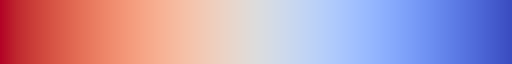

In [25]:
bias_cmap = matplotlib.colormaps['coolwarm_r']
bias_norm = matplotlib.colors.TwoSlopeNorm(vmin=-30, vcenter=0, vmax=80)
bias_cmap

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCS_SCA/figures_SPIReS/melt_out_differences_terrain_time.png


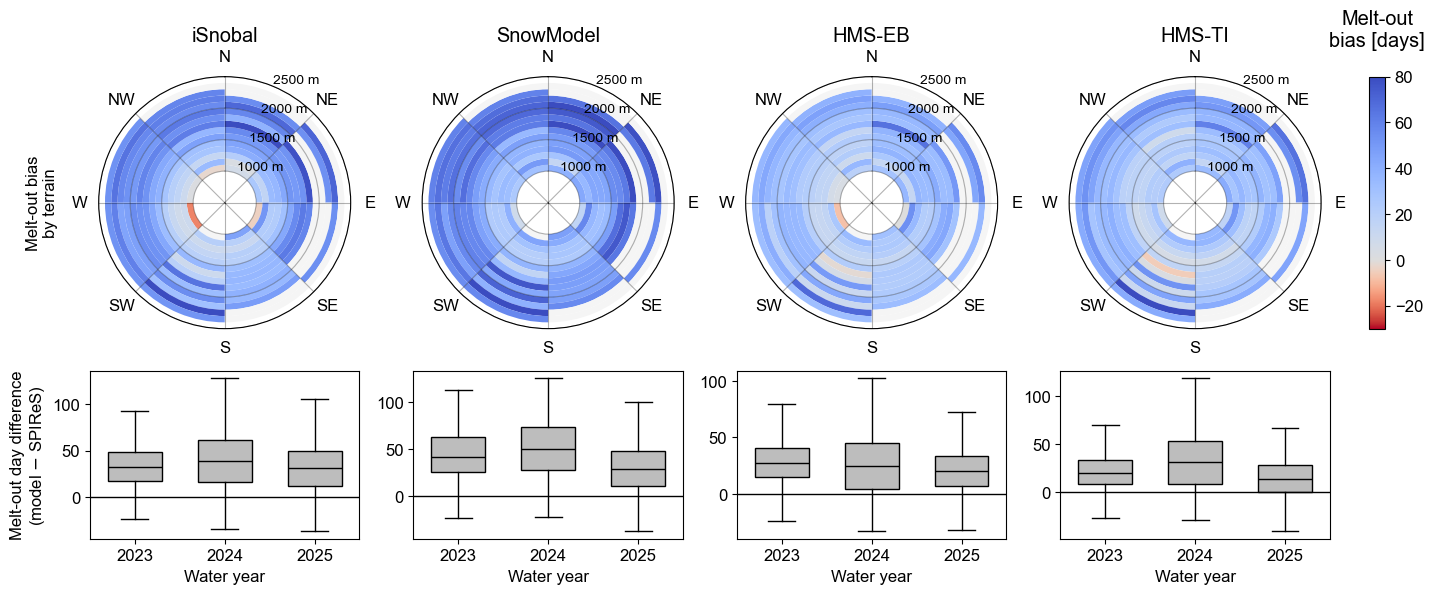

In [50]:
melt_out_binned = xr.open_dataset(MELT_OUT_BINNED_FILE, mask_and_scale=True).squeeze()
melt_out_grids = xr.open_dataset(MELT_OUT_GRIDS_FILE, mask_and_scale=True)

elev_bin_edges = np.array(melt_out_binned.attrs['elev_bins'])
aspect_bin_edges = np.array(melt_out_binned.attrs['aspect_bins'])
water_years = melt_out_grids.water_year.data
model_names = melt_out_binned.model.data
n_models = len(model_names)

fig = plt.figure(figsize=(4 * n_models, 6))
gs = fig.add_gridspec(2, n_models, height_ratios=[1.5, 1])

polar_axes, time_axes = [], []
for j, model in enumerate(model_names):
    da = melt_out_binned.sel(model=model)

    # --- Terrain polar panel: mean bias across water years, tasks, SWE thresholds ---
    ax_polar = fig.add_subplot(gs[0, j], projection='polar')
    da_mean = (
        da['melt_out_bias_days']
        .mean(dim='water_year', skipna=True)
        .max(dim='SWE_threshold_m', skipna=True)
        .mean(dim='task', skipna=True)
    )
    plot_recall_polar(
        da_mean, cmap=bias_cmap, cmap_norm=bias_norm, ax=ax_polar,
        elev_bin_edges=elev_bin_edges, aspect_bin_edges=aspect_bin_edges,
    )
    ax_polar.set_title(model)
    if j == 0:
        ax_polar.set_ylabel("Melt-out bias\nby terrain\n\n")
    polar_axes.append(ax_polar)

    # --- Interannual spread of pixel-level melt-out differences ---
    ax_time = fig.add_subplot(gs[1, j])
    model_grid = melt_out_grids['model_melt_out_dowy'].sel(model=model)

    diffs_by_year = []
    for wy in water_years:
        model_dowy = (
            model_grid.sel(water_year=wy)
            .max(dim='SWE_threshold_m', skipna=True)
            .mean(dim='task', skipna=True)
        )
        ref_dowy = melt_out_grids['SPIReS_melt_out_dowy'].sel(water_year=wy)
        diff = (model_dowy - ref_dowy).values.ravel()
        diffs_by_year.append(diff[~np.isnan(diff)])

    bp = ax_time.boxplot(
        diffs_by_year, positions=water_years, widths=0.6,
        showfliers=False, patch_artist=True,
        boxprops=dict(facecolor='#bdbdbd'),
        medianprops=dict(color="k", linewidth=1),
    )

    ax_time.axhline(0, color='k', lw=1, ls='-')
    ax_time.set_xlabel("Water year")
    ax_time.tick_params(axis='x')#, rotation=45)
    ax_time.set_xlim(2022.5, 2025.5)
    if j == 0:
        ax_time.set_ylabel("Melt-out day difference\n(model $-$ SPIReS)")
    time_axes.append(ax_time)

# Colorbar for the terrain row
ref_ax = polar_axes[-1]
pos = ref_ax.get_position()
c_ax = fig.add_axes([pos.x0 + pos.width + 0.03, pos.y0, 0.01, pos.height])
cbar = fig.colorbar(
    matplotlib.cm.ScalarMappable(cmap=bias_cmap, norm=bias_norm), cax=c_ax, 
    orientation='vertical', spacing='proportional'
)
cbar.ax.set_yscale('linear')
cbar.ax.set_title("Melt-out\nbias [days]\n")

fig_file = os.path.join(FIG_DIR, "melt_out_differences_terrain_time.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)
plt.show()

Figure saved to: /Users/rdcrlrka/Research/SIRO/MCS_SCA/figures_SPIReS/melt_out_differences_between_tasks.png


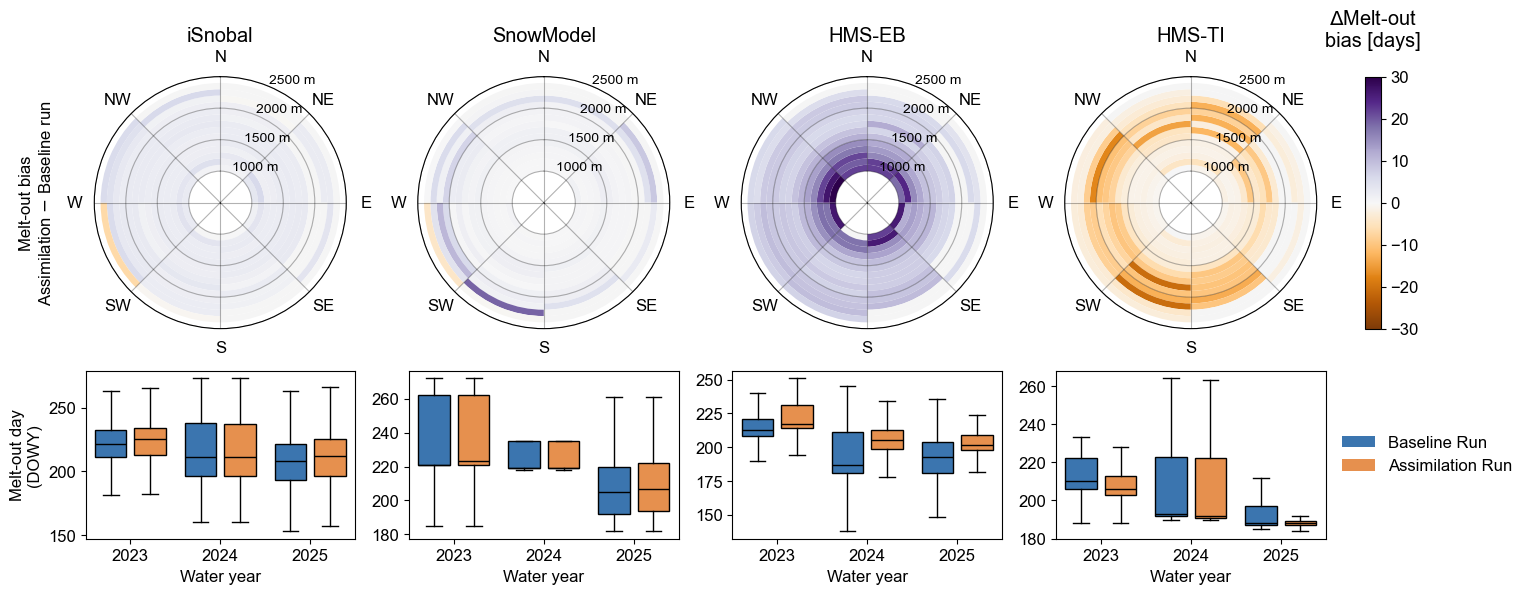

In [51]:
dbias_cmap = matplotlib.colormaps['PuOr']
dbias_norm = matplotlib.colors.TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30)

fig2 = plt.figure(figsize=(4 * n_models, 6))
gs2 = fig.add_gridspec(2, n_models, height_ratios=[1.5, 1])

task_colors = {1: '#3b75af', 2: '#e6904e'} 
box_width = 0.35
offset = 0.22

polar_axes2, time_axes2 = [], []
for j, model in enumerate(model_names):
    da = melt_out_binned.sel(model=model)

    # --- Terrain polar panel: unchanged, still Task 2 - Task 1 ---
    ax_polar = fig2.add_subplot(gs2[0, j], projection='polar')
    da_diff = (
        da['melt_out_bias_days']
        .mean(dim='water_year', skipna=True)
        .max(dim='SWE_threshold_m', skipna=True)
        .diff(dim='task')
        .squeeze()
    )
    plot_recall_polar(
        da_diff, cmap=dbias_cmap, cmap_norm=dbias_norm, ax=ax_polar,
        elev_bin_edges=elev_bin_edges, aspect_bin_edges=aspect_bin_edges,
    )
    ax_polar.set_title(model)
    if j == 0:
        ax_polar.set_ylabel("Melt-out bias\nAssimilation $-$ Baseline run\n\n")
    polar_axes2.append(ax_polar)

    # --- Interannual spread: each task's own distribution, side by side ---
    ax_time = fig2.add_subplot(gs2[1, j])
    model_grid = melt_out_grids['model_melt_out_dowy'].sel(model=model)

    for task, sign in zip(model_grid.task.values, (-1, 1)):
        task_dowy_by_year = model_grid.sel(task=task).max(dim='SWE_threshold_m', skipna=True)
        diffs_by_year = []
        for wy in water_years:
            vals = task_dowy_by_year.sel(water_year=wy).values.ravel()
            diffs_by_year.append(vals[~np.isnan(vals)])

        bp = ax_time.boxplot(
            diffs_by_year, positions=water_years + sign * offset, widths=box_width,
            showfliers=False, patch_artist=True,
            boxprops=dict(facecolor=task_colors[task]),
            medianprops=dict(color="k", linewidth=1),
        )

    ax_time.set_xticks(water_years)
    ax_time.set_xticklabels(water_years)
    ax_time.set_xlabel("Water year")
    ax_time.tick_params(axis='x')#, rotation=45)
    ax_time.set_xlim(2022.5, 2025.5)
    if j == 0:
        ax_time.set_ylabel("Melt-out day\n(DOWY)")
    time_axes2.append(ax_time)

# Legend for task colors (once, e.g. on the last time panel)
labels = ["Baseline Run", "Assimilation Run"]
legend_handles = [
    matplotlib.patches.Patch(facecolor=color, label=labels[i])
    for i, (task, color) in enumerate(task_colors.items())
]
time_axes2[-1].legend(
    handles=legend_handles, loc='center right', frameon=False,
    bbox_to_anchor=[1.55, 0.4, 0.2, 0.2]
    )

# Colorbar for the terrain row
ref_ax = polar_axes2[-1]
pos = ref_ax.get_position()
c_ax = fig2.add_axes([pos.x0 + pos.width + 0.03, pos.y0, 0.01, pos.height])
cbar = fig2.colorbar(
    matplotlib.cm.ScalarMappable(cmap=dbias_cmap, norm=dbias_norm), cax=c_ax,
    orientation='vertical', spacing='proportional'
)
cbar.ax.set_title("$\\Delta$Melt-out\nbias [days]\n")

fig2_file = os.path.join(FIG_DIR, "melt_out_differences_between_tasks.png")
fig2.savefig(fig2_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig2_file)
plt.show()

## Example processing figures

In [ ]:
aoi = gpd.read_file(AOI_FILE)

# SPIReS fSCA map
spires_fsca = xr.open_dataset(SPIRES_FSCA_FILE, mask_and_scale=True).snow_fraction
spires_fsca.name = "fSCA [%]"
fig, ax = plt.subplots()
time = spires_fsca.time.data[90]
spires_fsca.sel(time=time).plot(ax=ax, cmap=fsca_cmap, clim=(0,100), add_colorbar=False)
aoi.plot(facecolor='None', edgecolor='k', ax=ax)
ax.set_title(str(time)[0:10])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xlim(aoi.bounds.minx[0]-100, aoi.bounds.maxx[0]+100)
ax.set_ylim(aoi.bounds.miny[0]-100, aoi.bounds.maxy[0]+100)

ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

fig_file = os.path.join(FIG_DIR, 'example_SPIReS_fSCA_map.png')
fig.savefig(fig_file, dpi=250, bbox_inches='tight')
print("Figure saved to:", fig_file)

plt.show()